# Bayesian Final Project: Hierarchical Logistic Regression for Telco Churn

This notebook develops a **Bayesian hierarchical logistic regression** model for customer churn using the IBM telco churn dataset.

## Project goal
Model customer churn probability as a function of customer and service characteristics, while allowing the baseline churn rate to vary by **contract type** through a hierarchical prior.

## Why this model?
- The project guidelines require a Bayesian model with clearly described priors and MCMC details.
- Hierarchical models and generalized linear models are explicitly in scope.
- HMC/NUTS is out of scope, so we use a **Metropolis–Hastings MCMC** implementation instead.  

This notebook is organized in report style:
1. Data loading and cleaning
2. Exploratory data analysis
3. Hierarchical Bayesian logistic model
4. Metropolis–Hastings sampler
5. Diagnostics and posterior summaries
6. Interpretation


## Portfolio validation update

This notebook preserves the original full-sample course analysis. Its prediction scores are in sample. Its legacy ESS calculation concatenates chains and its R-hat is unsplit, so use `analysis/validate.py` and `results/mcmc_diagnostics.csv` for the audited chain diagnostics and `results/heldout_metrics.csv` for predictive claims. The validation sampler interweaves centered and non-centered updates to improve hyperparameter mixing.


## Reproducibility Notes

Run this notebook from the project root. The raw data are read from `data/WA_Fn-UseC_-Telco-Customer-Churn.csv`, and report-ready CSV summaries are written to `data/telco_hier_logit_notebook_outputs/`.

The full MCMC run uses four chains and can take a few minutes. For the submitted analysis, the important settings are documented in the sampler call: 45,000 iterations per chain, 12,000 warmup iterations, thinning by 3, and fixed post-warmup proposal scales.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import expit
from scipy.optimize import minimize
from numpy.random import default_rng

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
OUTDIR = Path("data/telco_hier_logit_notebook_outputs")
OUTDIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)


## 1. Load and clean the data

Key preprocessing choices:
- Convert `TotalCharges` to numeric and drop rows where it is blank.
- Drop `customerID` because it is only an identifier.
- Encode the binary response `Churn` as 0/1.
- Build predictors using a mix of numeric, binary, and one-hot encoded categorical variables.
- Omit `TotalCharges` from the regression because it is highly collinear with tenure and monthly charges, which makes coefficient interpretation unstable.


In [6]:
def load_and_prepare(csv_path: str):
    df = pd.read_csv(csv_path)
    raw_shape = df.shape

    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")
    n_missing_total = df["TotalCharges"].isna().sum()

    df = df.drop(columns=["customerID"]).dropna().copy()
    df["Churn"] = (df["Churn"] == "Yes").astype(int)

    for col in ["Partner", "Dependents", "PaperlessBilling"]:
        df[col] = (df[col] == "Yes").astype(int)
    for col in ["OnlineSecurity", "TechSupport"]:
        df[col] = (df[col] == "Yes").astype(int)

    X = pd.DataFrame({
        "tenure": df["tenure"].astype(float),
        "MonthlyCharges": df["MonthlyCharges"].astype(float),
        "SeniorCitizen": df["SeniorCitizen"].astype(float),
        "Partner": df["Partner"].astype(float),
        "Dependents": df["Dependents"].astype(float),
        "PaperlessBilling": df["PaperlessBilling"].astype(float),
        "OnlineSecurity": df["OnlineSecurity"].astype(float),
        "TechSupport": df["TechSupport"].astype(float),
    })

    X = pd.concat(
        [
            X,
            pd.get_dummies(df["InternetService"], prefix="InternetService", drop_first=True, dtype=float),
            pd.get_dummies(df["PaymentMethod"], prefix="PaymentMethod", drop_first=True, dtype=float),
        ],
        axis=1,
    )

    feature_names = list(X.columns)

    continuous = ["tenure", "MonthlyCharges"]
    means = X[continuous].mean()
    sds = X[continuous].std()
    X.loc[:, continuous] = (X[continuous] - means) / sds

    y = df["Churn"].to_numpy(int)
    X_mat = X.to_numpy(float)

    contract_codes, contract_levels = pd.factorize(df["Contract"])

    info = {
        "raw_shape": raw_shape,
        "n_missing_totalcharges": int(n_missing_total),
        "clean_shape": df.shape,
        "overall_churn_rate": float(df["Churn"].mean()),
    }

    return {
        "df": df,
        "X_df": X,
        "X": X_mat,
        "y": y,
        "feature_names": feature_names,
        "contract_codes": contract_codes,
        "contract_levels": list(contract_levels),
        "means": means,
        "sds": sds,
        "info": info,
    }

data = load_and_prepare(DATA_PATH)
df = data["df"]
X_df = data["X_df"]
X = data["X"]
y = data["y"]
feature_names = data["feature_names"]
contract_codes = data["contract_codes"]
contract_levels = data["contract_levels"]

data["info"]


{'raw_shape': (7043, 21),
 'n_missing_totalcharges': 11,
 'clean_shape': (7032, 20),
 'overall_churn_rate': 0.26578498293515357}

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,No,No phone service,DSL,0,Yes,No,0,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,Yes,No,DSL,1,No,Yes,0,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,Yes,No,DSL,1,Yes,No,0,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,No,No phone service,DSL,1,No,Yes,1,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,Yes,No,Fiber optic,0,No,No,0,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## 2. Descriptive statistics and EDA

The presentation guidelines explicitly ask for descriptive statistics and targeted plots rather than dumping every possible graphic. So we focus on:
- overall churn rate
- churn by contract type
- churn by internet service
- tenure by churn status
- monthly charges by churn status
- collinearity diagnostics for `TotalCharges`


In [9]:
summary_table = pd.DataFrame({
    "n": [len(df)],
    "overall_churn_rate": [df["Churn"].mean()],
    "mean_tenure": [df["tenure"].mean()],
    "mean_monthly_charges": [df["MonthlyCharges"].mean()],
    "corr_tenure_totalcharges": [df[["tenure", "TotalCharges"]].corr().iloc[0, 1]],
    "corr_monthly_totalcharges": [df[["MonthlyCharges", "TotalCharges"]].corr().iloc[0, 1]],
})
summary_table


,n,overall_churn_rate,mean_tenure,mean_monthly_charges,corr_tenure_totalcharges,corr_monthly_totalcharges
0,7032,0.2658,32.4218,64.7982,0.8259,0.6511


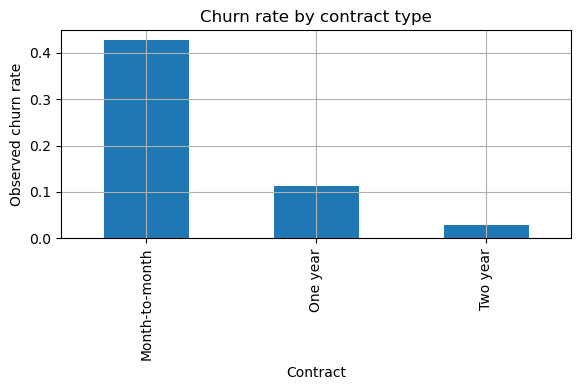

Contract
Month-to-month    0.4271
One year          0.1128
Two year          0.0285
Name: Churn, dtype: float64

In [10]:
churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
churn_by_internet = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
churn_by_contract.plot(kind="bar", ax=ax)
ax.set_ylabel("Observed churn rate")
ax.set_title("Churn rate by contract type")
plt.tight_layout()
plt.show()

churn_by_contract


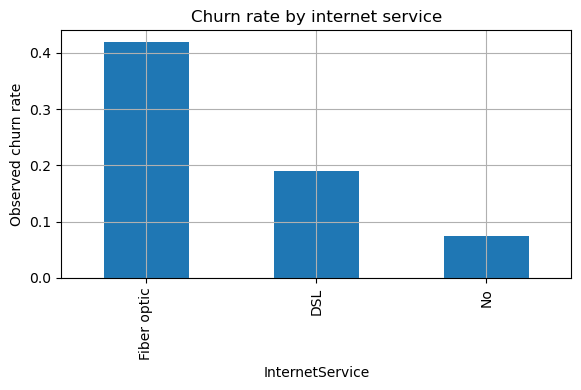

InternetService
Fiber optic    0.4189
DSL            0.1900
No             0.0743
Name: Churn, dtype: float64

In [11]:
fig, ax = plt.subplots()
churn_by_internet.plot(kind="bar", ax=ax)
ax.set_ylabel("Observed churn rate")
ax.set_title("Churn rate by internet service")
plt.tight_layout()
plt.show()

churn_by_internet


### Payment method and service-support EDA

The posterior model later identifies electronic check payment, online security, and tech support as important predictors. These summaries make that part of the modeling story visible before the regression.


,churn_rate,n
PaymentMethod,,
Electronic check,0.4529,2365
Mailed check,0.1920,1604
Bank transfer (automatic),0.1673,1542
Credit card (automatic),0.1525,1521


,OnlineSecurity=Yes,TechSupport=Yes
No,0.3137,0.3123
Yes,0.1464,0.1520


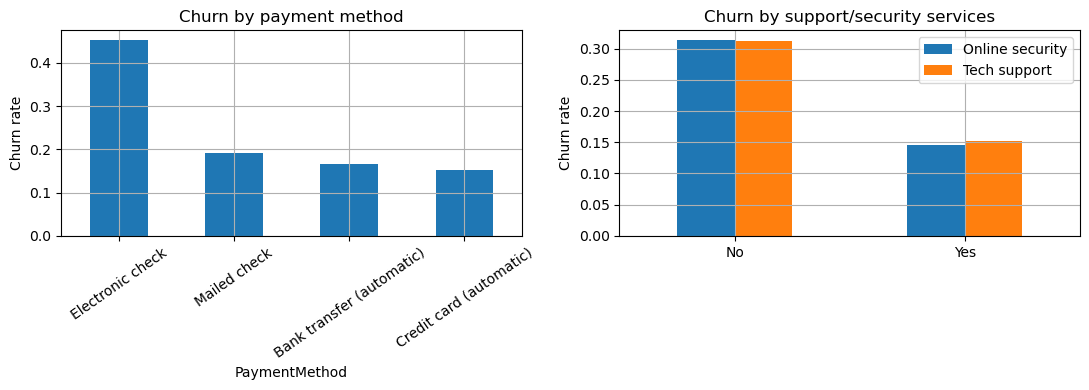

In [13]:
payment_summary = (
    df.groupby("PaymentMethod")["Churn"]
    .agg(churn_rate="mean", n="size")
    .sort_values("churn_rate", ascending=False)
)

service_support_summary = pd.DataFrame({
    "OnlineSecurity=Yes": df.groupby("OnlineSecurity")["Churn"].mean().rename(index={0: "No", 1: "Yes"}),
    "TechSupport=Yes": df.groupby("TechSupport")["Churn"].mean().rename(index={0: "No", 1: "Yes"}),
})

display(payment_summary)
display(service_support_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
payment_summary["churn_rate"].plot(kind="bar", ax=axes[0])
axes[0].set_ylabel("Churn rate")
axes[0].set_title("Churn by payment method")
axes[0].tick_params(axis="x", rotation=35)

service_plot = pd.DataFrame({
    "Online security": df.groupby("OnlineSecurity")["Churn"].mean().rename(index={0: "No", 1: "Yes"}),
    "Tech support": df.groupby("TechSupport")["Churn"].mean().rename(index={0: "No", 1: "Yes"}),
})
service_plot.plot(kind="bar", ax=axes[1])
axes[1].set_ylabel("Churn rate")
axes[1].set_title("Churn by support/security services")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


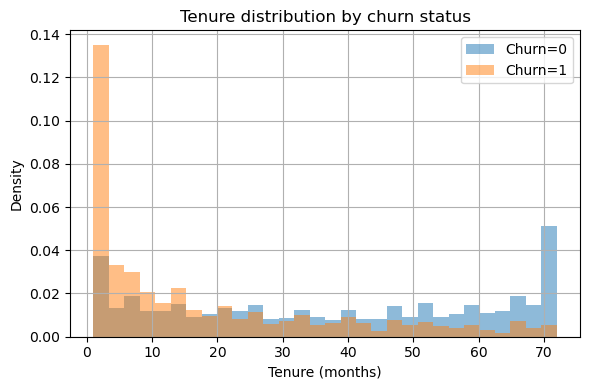

In [14]:
fig, ax = plt.subplots()
for value, grp in df.groupby("Churn"):
    ax.hist(grp["tenure"], bins=30, alpha=0.5, density=True, label=f"Churn={value}")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Density")
ax.set_title("Tenure distribution by churn status")
ax.legend()
plt.tight_layout()
plt.show()


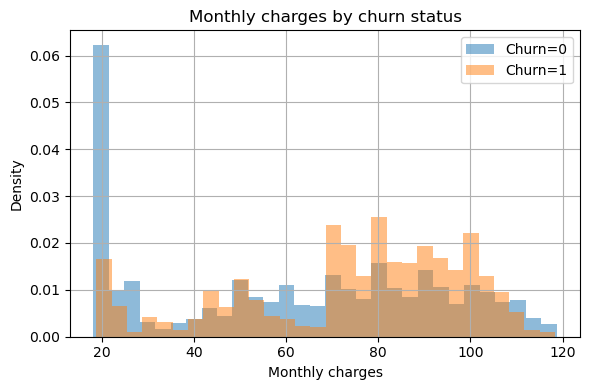

In [15]:
fig, ax = plt.subplots()
for value, grp in df.groupby("Churn"):
    ax.hist(grp["MonthlyCharges"], bins=30, alpha=0.5, density=True, label=f"Churn={value}")
ax.set_xlabel("Monthly charges")
ax.set_ylabel("Density")
ax.set_title("Monthly charges by churn status")
ax.legend()
plt.tight_layout()
plt.show()


### EDA takeaways

The main empirical patterns are:
- **Month-to-month customers churn much more often** than customers on longer contracts.
- **Fiber optic customers churn more** than DSL or no-internet customers in this dataset.
- **Electronic check customers churn more** than customers using automatic payment methods.
- Customers with **online security** or **tech support** have lower observed churn rates.
- Customers who churn tend to have **shorter tenure**.
- Customers who churn often have **higher monthly charges**.
- `TotalCharges` is strongly tied to tenure and monthly charges, so excluding it improves interpretability.

These patterns motivate the model structure: a contract-type hierarchy for baseline churn risk, plus customer-level predictors for tenure, charges, service type, billing, and support/security features.


## 3. Hierarchical Bayesian logistic model

Let $y_i$ be the churn indicator for customer $i$, and let $g[i]$ denote the contract-type group for that customer.

$$
y_i \sim \text{Bernoulli}(p_i)
$$

$$
\text{logit}(p_i) = \alpha_{g[i]} + x_i^\top \beta
$$

We place a hierarchical prior on the group-specific intercepts:

$$
\alpha_g \sim \mathcal{N}(\mu_\alpha,\tau_\alpha^2)
$$

with priors

$$
\beta_j \sim \mathcal{N}(0, 2.5^2), \qquad
\mu_\alpha \sim \mathcal{N}(0, 5^2), \qquad
\tau_\alpha \sim \text{Half-Normal}(2.5).
$$

### Why this hierarchy?
Contract type is a natural grouping variable in churn data:
- month-to-month
- one year
- two year

Instead of fitting three completely separate intercepts with no structure, the hierarchical prior partially pools them toward a common mean. That gives more stable estimation and is a strong Bayesian justification for using a multilevel model.


## 4. Metropolis-Hastings implementation

Because this is a **hierarchical logistic regression**, the posterior is not conjugate. We therefore use a block random-walk Metropolis-Hastings sampler.

The first version of this notebook sampled the group intercepts directly as

$$
\alpha_g \sim \mathcal{N}(\mu_\alpha, \tau_\alpha^2).
$$

That centered parameterization is statistically correct, but it can mix poorly because the group intercepts, group mean, and group standard deviation are strongly posterior-correlated. The low effective sample sizes for the intercepts were a symptom of that geometry.

Here we use a **non-centered parameterization**:

$$
z_g \sim \mathcal{N}(0,1), \qquad \alpha_g = \mu_\alpha + \tau_\alpha z_g.
$$

This keeps the same model, but it often gives a smoother posterior for random-walk Metropolis. During warmup only, the proposal scales are adapted toward a target acceptance rate near 0.30. All reported posterior draws are collected after adaptation has stopped.


### Sampler Helper Functions

The next cell defines all reusable MCMC and diagnostic helpers:

- `autocorr` and `ess_1d` estimate autocorrelation and effective sample size.
- `rhat` checks agreement across chains.
- `summarize_chains` pools draws and reports posterior summaries.
- `fit_hierarchical_logistic_mh_nc` implements the non-centered Metropolis-Hastings sampler.

Keeping these functions in one cell makes the computational solution easier to audit and rerun.


In [20]:
def autocorr(x: np.ndarray, max_lag: int = 200) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    var = np.dot(x, x) / n
    if var == 0:
        return np.zeros(max_lag + 1)
    out = [1.0]
    for lag in range(1, min(max_lag, n - 1) + 1):
        out.append(np.dot(x[:-lag], x[lag:]) / ((n - lag) * var))
    return np.asarray(out)


def ess_1d(x: np.ndarray, max_lag: int = 500) -> float:
    rho = autocorr(x, max_lag=max_lag)[1:]
    s = 0.0
    for k in range(0, len(rho) - 1, 2):
        pair = rho[k] + rho[k + 1]
        if pair < 0:
            break
        s += pair
    return len(x) / (1 + 2 * s)


def rhat(chains: np.ndarray) -> float:
    chains = np.asarray(chains, dtype=float)
    m, n = chains.shape
    chain_means = chains.mean(axis=1)
    chain_vars = chains.var(axis=1, ddof=1)
    W = chain_vars.mean()
    B = n * chain_means.var(ddof=1)
    if W == 0:
        return 1.0
    var_hat = ((n - 1) / n) * W + B / n
    return float(np.sqrt(var_hat / W))


def summarize_chains(chain_draws: np.ndarray, param_names: list[str]) -> pd.DataFrame:
    rows = []
    for j, name in enumerate(param_names):
        by_chain = chain_draws[:, :, j]
        pooled = by_chain.reshape(-1)
        rows.append({
            "parameter": name,
            "mean": pooled.mean(),
            "sd": pooled.std(ddof=1),
            "q2.5": np.quantile(pooled, 0.025),
            "median": np.quantile(pooled, 0.5),
            "q97.5": np.quantile(pooled, 0.975),
            "ess_bulk_approx": ess_1d(pooled),
            "rhat": rhat(by_chain),
        })
    return pd.DataFrame(rows)


def fit_hierarchical_logistic_mh_nc(
    X,
    y,
    contract_codes,
    n_groups,
    n_iter=22000,
    burn=8000,
    thin=3,
    seed=0,
    trace_stride=5,
    target_accept=0.30,
    adapt_interval=250,
):
    rng = default_rng(seed)
    n, p = X.shape

    def logpost(beta, z_alpha, mu_alpha, eta_tau):
        tau_alpha = np.exp(eta_tau)
        alpha = mu_alpha + tau_alpha * z_alpha
        lin = alpha[contract_codes] + X @ beta
        loglik = np.sum(y * lin - np.logaddexp(0, lin))

        logprior_beta = -0.5 * np.sum((beta / 2.5) ** 2) - p * np.log(2.5 * np.sqrt(2 * np.pi))
        logprior_z = -0.5 * np.sum(z_alpha ** 2) - n_groups * np.log(np.sqrt(2 * np.pi))
        logprior_mu = -0.5 * (mu_alpha / 5.0) ** 2 - np.log(5.0 * np.sqrt(2 * np.pi))

        sigma_tau = 2.5
        tau = np.exp(eta_tau)
        logprior_tau = np.log(np.sqrt(2) / (sigma_tau * np.sqrt(np.pi))) - 0.5 * (tau / sigma_tau) ** 2 + eta_tau

        return loglik + logprior_beta + logprior_z + logprior_mu + logprior_tau

    beta = rng.normal(scale=0.05, size=p)
    z_alpha = rng.normal(scale=0.4, size=n_groups)
    mu_alpha = np.log(y.mean() / (1 - y.mean())) + rng.normal(scale=0.15)
    eta_tau = np.log(0.8) + rng.normal(scale=0.15)
    current_lp = logpost(beta, z_alpha, mu_alpha, eta_tau)

    steps = np.array([0.035, 0.16, 0.22, 0.22], dtype=float)
    accepts_total = np.zeros(4)
    accepts_window = np.zeros(4)
    proposals_total = np.zeros(4)
    proposals_window = np.zeros(4)
    draws = []
    trace_small = []
    step_history = []

    for it in range(n_iter):
        beta_prop = beta + rng.normal(scale=steps[0], size=p)
        lp_prop = logpost(beta_prop, z_alpha, mu_alpha, eta_tau)
        proposals_total[0] += 1
        proposals_window[0] += 1
        if np.log(rng.random()) < lp_prop - current_lp:
            beta = beta_prop
            current_lp = lp_prop
            accepts_total[0] += 1
            accepts_window[0] += 1

        z_prop = z_alpha + rng.normal(scale=steps[1], size=n_groups)
        lp_prop = logpost(beta, z_prop, mu_alpha, eta_tau)
        proposals_total[1] += 1
        proposals_window[1] += 1
        if np.log(rng.random()) < lp_prop - current_lp:
            z_alpha = z_prop
            current_lp = lp_prop
            accepts_total[1] += 1
            accepts_window[1] += 1

        mu_prop = mu_alpha + rng.normal(scale=steps[2])
        lp_prop = logpost(beta, z_alpha, mu_prop, eta_tau)
        proposals_total[2] += 1
        proposals_window[2] += 1
        if np.log(rng.random()) < lp_prop - current_lp:
            mu_alpha = mu_prop
            current_lp = lp_prop
            accepts_total[2] += 1
            accepts_window[2] += 1

        eta_prop = eta_tau + rng.normal(scale=steps[3])
        lp_prop = logpost(beta, z_alpha, mu_alpha, eta_prop)
        proposals_total[3] += 1
        proposals_window[3] += 1
        if np.log(rng.random()) < lp_prop - current_lp:
            eta_tau = eta_prop
            current_lp = lp_prop
            accepts_total[3] += 1
            accepts_window[3] += 1

        if it % trace_stride == 0 or it == n_iter - 1:
            tau_alpha = np.exp(eta_tau)
            alpha = mu_alpha + tau_alpha * z_alpha
            trace_small.append([
                seed,
                it,
                current_lp,
                beta[0],
                beta[1],
                alpha[0],
                alpha[1] if n_groups > 1 else np.nan,
                alpha[2] if n_groups > 2 else np.nan,
                mu_alpha,
                tau_alpha,
                z_alpha[0],
                steps[0],
                steps[1],
                steps[2],
                steps[3],
            ])

        if it < burn and (it + 1) % adapt_interval == 0:
            window_rates = accepts_window / np.maximum(proposals_window, 1)
            steps *= np.exp(0.75 * (window_rates - target_accept))
            steps = np.clip(steps, 0.005, 1.5)
            step_history.append([seed, it + 1, *window_rates, *steps])
            accepts_window[:] = 0
            proposals_window[:] = 0

        if it >= burn and (it - burn) % thin == 0:
            draws.append(np.r_[beta, alpha, mu_alpha, tau_alpha])

    return {
        "draws": np.asarray(draws),
        "acceptance_rates": accepts_total / np.maximum(proposals_total, 1),
        "trace": np.asarray(trace_small),
        "step_history": np.asarray(step_history),
        "final_steps": steps.copy(),
    }


### Run Four MCMC Chains

This cell is the main computational step. Multiple chains are used so that trace plots and \(\hat{R}\) diagnostics can detect non-convergence or poor mixing. The final output is stored as both a per-chain array (`chain_draws`) and a pooled draw matrix (`samples`).


In [22]:
chain_results = []
for seed in [11, 22, 33, 44]:
    chain_results.append(
        fit_hierarchical_logistic_mh_nc(
            X,
            y,
            contract_codes,
            len(contract_levels),
            n_iter=45000,
            burn=12000,
            thin=3,
            seed=seed,
        )
    )

param_names = feature_names + [f"alpha[{c}]" for c in contract_levels] + ["mu_alpha", "tau_alpha"]
chain_draws = np.stack([res["draws"] for res in chain_results])
samples = chain_draws.reshape(-1, chain_draws.shape[-1])
summary = summarize_chains(chain_draws, param_names)

acceptance_rates = pd.DataFrame(
    [res["acceptance_rates"] for res in chain_results],
    columns=["beta", "z_alpha", "mu_alpha", "tau_alpha"],
)
acceptance_rates.insert(0, "chain", np.arange(1, len(chain_results) + 1))
acceptance_rates


,chain,beta,z_alpha,mu_alpha,tau_alpha
0,1,0.2879,0.2393,0.2996,0.2878
1,2,0.2947,0.3003,0.2967,0.2405
2,3,0.2833,0.3414,0.2927,0.2445
3,4,0.3082,0.3388,0.2971,0.3641


## 5. Diagnostics

We now check the sampler in the way we would want to describe it in a Bayesian report:

- block acceptance rates, ideally roughly in the 0.20-0.50 range for random-walk proposals
- trace plots across multiple chains
- ACF plots for the slowest and most important parameters
- approximate effective sample sizes
- split-chain consistency through \(\hat{R}\), with values near 1 indicating that chains agree

The ESS calculation here is intentionally lightweight and course-friendly. It is enough to flag problematic autocorrelation, but for production Bayesian work I would use ArviZ or Stan-style rank-normalized diagnostics.


In [24]:
trace_columns = [
    "chain_seed",
    "iteration",
    "logpost",
    "beta_tenure",
    "beta_monthly",
    "alpha_month",
    "alpha_one",
    "alpha_two",
    "mu_alpha",
    "tau_alpha",
    "z_alpha_month",
    "step_beta",
    "step_z_alpha",
    "step_mu_alpha",
    "step_tau_alpha",
]
trace_df = pd.concat(
    [pd.DataFrame(res["trace"], columns=trace_columns).assign(chain=i + 1) for i, res in enumerate(chain_results)],
    ignore_index=True,
)

step_history_columns = [
    "chain_seed",
    "iteration",
    "accept_beta",
    "accept_z_alpha",
    "accept_mu_alpha",
    "accept_tau_alpha",
    "step_beta",
    "step_z_alpha",
    "step_mu_alpha",
    "step_tau_alpha",
]
step_history = pd.concat(
    [pd.DataFrame(res["step_history"], columns=step_history_columns).assign(chain=i + 1) for i, res in enumerate(chain_results)],
    ignore_index=True,
)

final_steps = pd.DataFrame(
    [res["final_steps"] for res in chain_results],
    columns=["step_beta", "step_z_alpha", "step_mu_alpha", "step_tau_alpha"],
)
final_steps.insert(0, "chain", np.arange(1, len(chain_results) + 1))

acceptance_rates, final_steps


(   chain    beta  z_alpha  mu_alpha  tau_alpha
 0      1  0.2879   0.2393    0.2996     0.2878
 1      2  0.2947   0.3003    0.2967     0.2405
 2      3  0.2833   0.3414    0.2927     0.2445
 3      4  0.3082   0.3388    0.2971     0.3641,
    chain  step_beta  step_z_alpha  step_mu_alpha  step_tau_alpha
 0      1     0.0338        0.1411         0.1226          0.1799
 1      2     0.0335        0.0978         0.1274          0.2722
 2      3     0.0345        0.0921         0.1313          0.2682
 3      4     0.0321        0.0946         0.1237          0.1591)

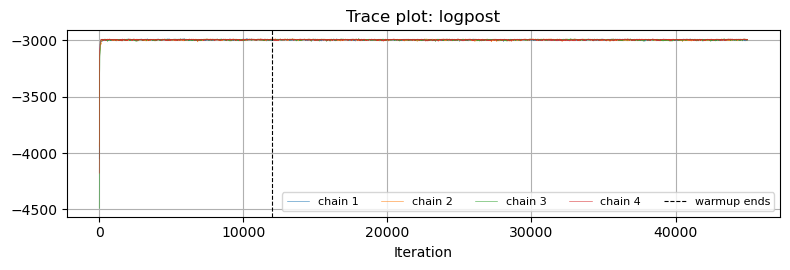

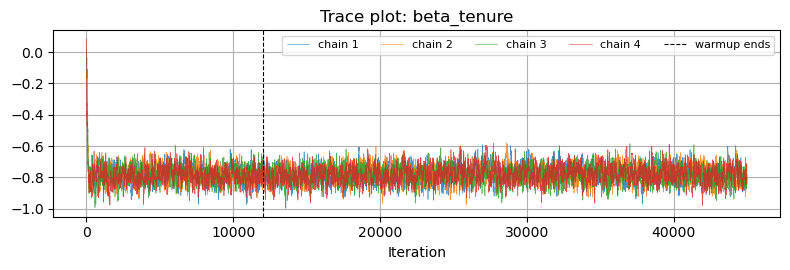

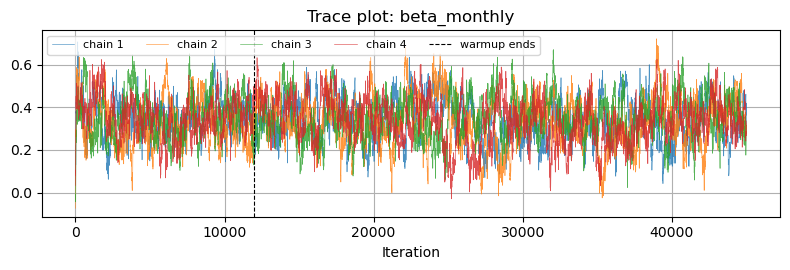

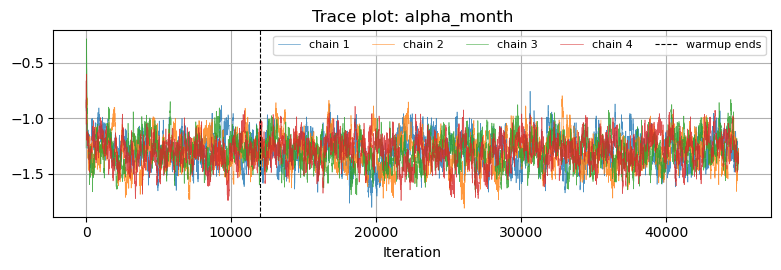

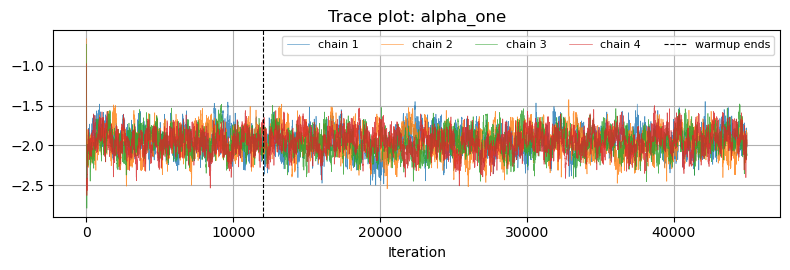

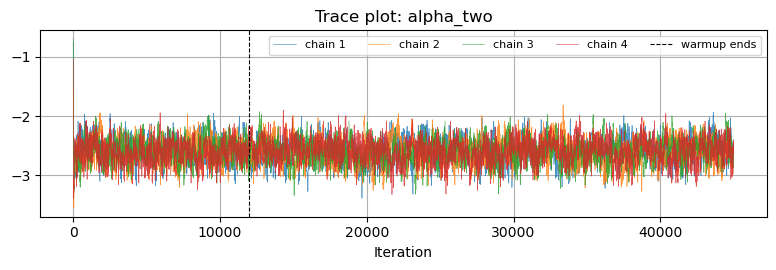

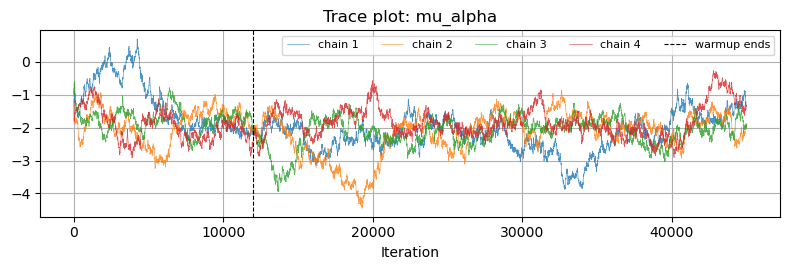

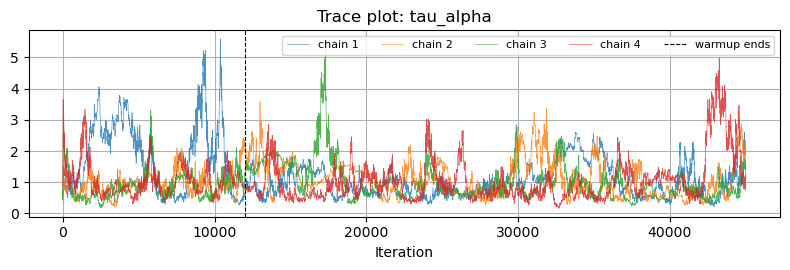

In [25]:
selected = ["logpost", "beta_tenure", "beta_monthly", "alpha_month", "alpha_one", "alpha_two", "mu_alpha", "tau_alpha"]

for name in selected:
    fig, ax = plt.subplots(figsize=(8, 2.8))
    for chain, grp in trace_df.groupby("chain"):
        ax.plot(grp["iteration"], grp[name], linewidth=0.45, alpha=0.8, label=f"chain {chain}")
    ax.axvline(12000, color="black", linestyle="--", linewidth=0.8, label="warmup ends")
    ax.set_title(f"Trace plot: {name}")
    ax.set_xlabel("Iteration")
    ax.legend(ncol=5, fontsize=8)
    plt.tight_layout()
    plt.show()


In [26]:
diag_table = summary.sort_values(["rhat", "ess_bulk_approx"], ascending=[False, True])
diag_table.head(12)


,parameter,mean,sd,q2.5,median,q97.5,ess_bulk_approx,rhat
16,mu_alpha,-2.0938,0.5612,-3.5474,-2.0348,-1.0882,62.5878,1.0584
17,tau_alpha,1.0485,0.6023,0.3672,0.8850,2.5319,94.4660,1.0038
12,PaymentMethod_Mailed check,-0.0165,0.1147,-0.2412,-0.0177,0.2041,479.3522,1.0033
6,OnlineSecurity,-0.4552,0.0851,-0.6239,-0.4543,-0.2912,1091.6883,1.0029
1,MonthlyCharges,0.3385,0.1034,0.1256,0.3384,0.5358,270.4755,1.0023
11,PaymentMethod_Electronic check,0.3681,0.0940,0.1856,0.3680,0.5508,529.3775,1.0022
8,InternetService_Fiber optic,0.4987,0.1443,0.2200,0.4999,0.7866,292.0722,1.0021
5,PaperlessBilling,0.3708,0.0749,0.2233,0.3697,0.5206,1248.5523,1.0021
9,InternetService_No,-0.7651,0.1586,-1.0709,-0.7660,-0.4618,276.1568,1.0018
10,PaymentMethod_Credit card (automatic),-0.0765,0.1142,-0.2984,-0.0769,0.1488,479.7305,1.0017


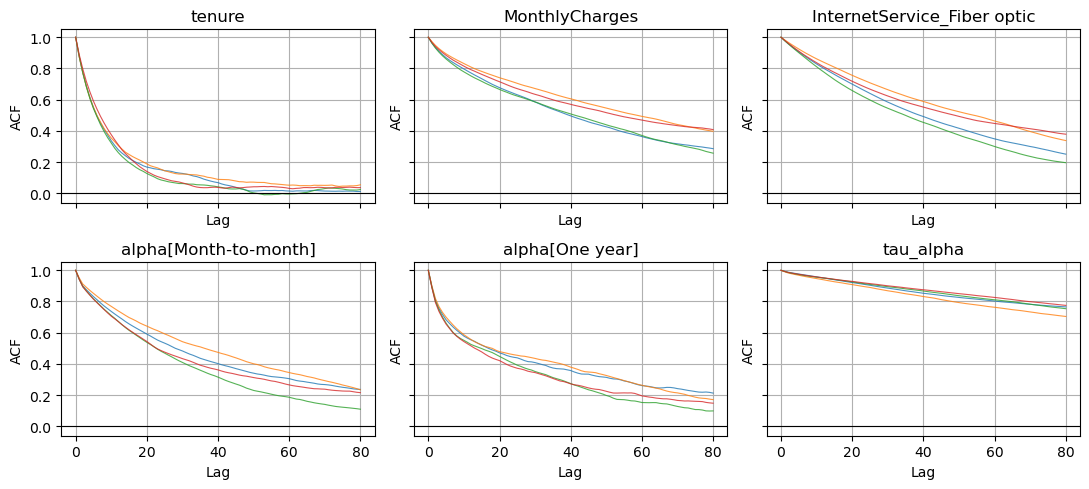

In [27]:
acf_params = ["tenure", "MonthlyCharges", "InternetService_Fiber optic", "alpha[Month-to-month]", "alpha[One year]", "tau_alpha"]
summary_index = {name: i for i, name in enumerate(param_names)}

fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), acf_params):
    j = summary_index[name]
    for c in range(chain_draws.shape[0]):
        ac = autocorr(chain_draws[c, :, j], max_lag=80)
        ax.plot(np.arange(len(ac)), ac, linewidth=0.8, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
plt.tight_layout()
plt.show()


### Diagnostic takeaways

The non-centered parameterization materially improves the diagnostics for the substantive parameters. The contract intercepts now have approximate ESS values in the hundreds and R-hat values very close to 1. The fixed effects also mix much better than in the centered run.

The weakest remaining parameter is `mu_alpha`, the population mean of the contract intercepts. This is not surprising because there are only three contract groups, so the hyper-mean is weakly identified compared with the group intercepts themselves. The report should therefore emphasize the posterior for `alpha[Month-to-month]`, `alpha[One year]`, `alpha[Two year]`, and the fixed effects, while treating `mu_alpha` and `tau_alpha` as supporting hyperparameters rather than primary scientific conclusions.


## 6. Posterior summaries

We now summarize the posterior means, standard deviations, and 95% credible intervals.
For standardized continuous predictors:
- a negative coefficient means lower churn probability as the predictor increases
- a positive coefficient means higher churn probability as the predictor increases


In [30]:
summary.sort_values("mean")

,parameter,mean,sd,q2.5,median,q97.5,ess_bulk_approx,rhat
15,alpha[Two year],-2.5935,0.1985,-2.9921,-2.5898,-2.2135,867.2016,1.0017
16,mu_alpha,-2.0938,0.5612,-3.5474,-2.0348,-1.0882,62.5878,1.0584
14,alpha[One year],-1.9537,0.1497,-2.2518,-1.9523,-1.6649,603.5797,1.0015
13,alpha[Month-to-month],-1.2940,0.1355,-1.5615,-1.2917,-1.0336,481.6850,1.0010
0,tenure,-0.7807,0.0535,-0.8850,-0.7813,-0.6766,1743.1331,1.0000
9,InternetService_No,-0.7651,0.1586,-1.0709,-0.7660,-0.4618,276.1568,1.0018
6,OnlineSecurity,-0.4552,0.0851,-0.6239,-0.4543,-0.2912,1091.6883,1.0029
7,TechSupport,-0.3951,0.0879,-0.5680,-0.3950,-0.2219,998.8823,1.0001
4,Dependents,-0.1814,0.0886,-0.3554,-0.1805,-0.0070,1082.2967,1.0003
10,PaymentMethod_Credit card (automatic),-0.0765,0.1142,-0.2984,-0.0769,0.1488,479.7305,1.0017


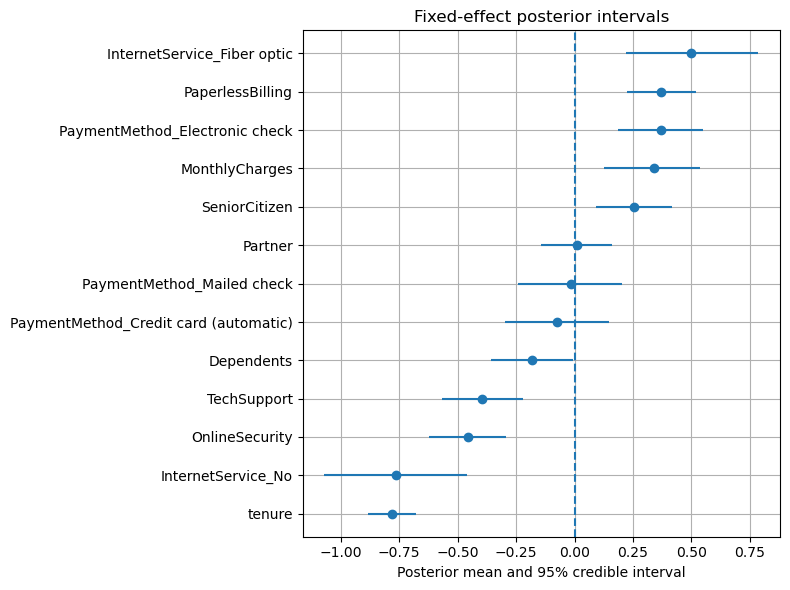

In [31]:
fixed = summary[
    ~summary["parameter"].str.startswith("alpha[") & ~summary["parameter"].isin(["mu_alpha", "tau_alpha"])
].copy().sort_values("mean")

y_pos = np.arange(len(fixed))
plt.figure(figsize=(8, 6))
plt.errorbar(
    fixed["mean"],
    y_pos,
    xerr=[fixed["mean"] - fixed["q2.5"], fixed["q97.5"] - fixed["mean"]],
    fmt="o",
)
plt.axvline(0.0, linestyle="--")
plt.yticks(y_pos, fixed["parameter"])
plt.xlabel("Posterior mean and 95% credible interval")
plt.title("Fixed-effect posterior intervals")
plt.tight_layout()
plt.show()


In [32]:
alpha_rows = summary[summary["parameter"].str.startswith("alpha[")].copy()
alpha_rows


,parameter,mean,sd,q2.5,median,q97.5,ess_bulk_approx,rhat
13,alpha[Month-to-month],-1.2940,0.1355,-1.5615,-1.2917,-1.0336,481.6850,1.0010
14,alpha[One year],-1.9537,0.1497,-2.2518,-1.9523,-1.6649,603.5797,1.0015
15,alpha[Two year],-2.5935,0.1985,-2.9921,-2.5898,-2.2135,867.2016,1.0017


### Posterior probability summaries

A useful Bayesian reporting move is to translate coefficient draws into directional probabilities and odds-ratio intervals. This is more informative than only saying whether a 95% interval crosses zero.


In [34]:
posterior_effect_rows = []
for name in feature_names:
    j = param_names.index(name)
    draws = samples[:, j]
    odds = np.exp(draws)
    posterior_effect_rows.append({
        "parameter": name,
        "Pr(beta > 0)": np.mean(draws > 0),
        "Pr(beta < 0)": np.mean(draws < 0),
        "odds_ratio_median": np.median(odds),
        "odds_ratio_q2.5": np.quantile(odds, 0.025),
        "odds_ratio_q97.5": np.quantile(odds, 0.975),
    })

posterior_effect_probs = pd.DataFrame(posterior_effect_rows)
posterior_effect_probs["direction_certainty"] = posterior_effect_probs[["Pr(beta > 0)", "Pr(beta < 0)"]].max(axis=1)
posterior_effect_probs.sort_values("direction_certainty", ascending=False)


,parameter,Pr(beta > 0),Pr(beta < 0),odds_ratio_median,odds_ratio_q2.5,odds_ratio_q97.5,direction_certainty
0,tenure,0.0000,1.0000e+00,0.4578,0.4127,0.5084,1.0000
5,PaperlessBilling,1.0000,0.0000e+00,1.4473,1.2502,1.6831,1.0000
6,OnlineSecurity,0.0000,1.0000e+00,0.6349,0.5359,0.7474,1.0000
7,TechSupport,0.0000,1.0000e+00,0.6737,0.5667,0.8010,1.0000
9,InternetService_No,0.0000,1.0000e+00,0.4649,0.3427,0.6301,1.0000
11,PaymentMethod_Electronic check,1.0000,2.2727e-05,1.4449,1.2039,1.7347,1.0000
8,InternetService_Fiber optic,0.9998,1.8182e-04,1.6485,1.2460,2.1960,0.9998
1,MonthlyCharges,0.9994,5.9091e-04,1.4028,1.1339,1.7088,0.9994
2,SeniorCitizen,0.9990,1.0227e-03,1.2892,1.0969,1.5160,0.9990
4,Dependents,0.0204,9.7957e-01,0.8348,0.7009,0.9930,0.9796


## 7. Posterior predictive summary

Instead of using only posterior means, we compute predictions for a subset of posterior draws. This gives a posterior mean predicted probability for each customer and lets us report predictive uncertainty for aggregate churn.

The metrics below are still in-sample, so they should be treated as model-fit summaries rather than out-of-sample validation.


In [36]:
rng = default_rng(2026)
posterior_draw_idx = rng.choice(samples.shape[0], size=min(1200, samples.shape[0]), replace=False)
posterior_probs = np.empty((len(posterior_draw_idx), len(y)))

for row, draw_idx in enumerate(posterior_draw_idx):
    draw = samples[draw_idx]
    beta_draw = draw[:len(feature_names)]
    alpha_draw = draw[len(feature_names):len(feature_names) + len(contract_levels)]
    posterior_probs[row] = expit(alpha_draw[contract_codes] + X @ beta_draw)

p_hat = posterior_probs.mean(axis=0)
y_hat = (p_hat >= 0.5).astype(int)
aggregate_churn = posterior_probs.mean(axis=1)

metrics = pd.DataFrame([{
    "accuracy_at_0.5": (y_hat == y).mean(),
    "brier_score": np.mean((p_hat - y) ** 2),
    "log_loss": -np.mean(
        y * np.log(np.clip(p_hat, 1e-12, 1)) +
        (1 - y) * np.log(np.clip(1 - p_hat, 1e-12, 1))
    ),
    "posterior_mean_churn": aggregate_churn.mean(),
    "posterior_churn_q2.5": np.quantile(aggregate_churn, 0.025),
    "posterior_churn_q97.5": np.quantile(aggregate_churn, 0.975),
}])

metrics


,accuracy_at_0.5,brier_score,log_loss,posterior_mean_churn,posterior_churn_q2.5,posterior_churn_q97.5
0,0.7996,0.1367,0.42,0.2658,0.2565,0.275


## 8. Frequentist baseline comparison

The frequentist logistic regression is not a straw man: it is a strong and interpretable baseline. The Bayesian model should therefore be presented as an inferential improvement, not as a large predictive-performance improvement. We fit a comparable frequentist logistic model with the same customer-level predictors plus fixed contract-type indicators.


In [38]:
contract_dummies = pd.get_dummies(df["Contract"], prefix="Contract", drop_first=True, dtype=float)
X_freq = pd.concat([X_df.reset_index(drop=True), contract_dummies.reset_index(drop=True)], axis=1)
X_design = np.column_stack([np.ones(len(X_freq)), X_freq.to_numpy(float)])
freq_param_names = ["const"] + list(X_freq.columns)


def neg_loglik_logit(theta):
    lin = X_design @ theta
    return -np.sum(y * lin - np.logaddexp(0, lin))


def grad_neg_loglik_logit(theta):
    p = expit(X_design @ theta)
    return X_design.T @ (p - y)

freq_fit = minimize(
    neg_loglik_logit,
    x0=np.zeros(X_design.shape[1]),
    jac=grad_neg_loglik_logit,
    method="BFGS",
    options={"maxiter": 500, "gtol": 1e-6},
)

freq_params = pd.Series(freq_fit.x, index=freq_param_names)
# BFGS returns an approximate inverse Hessian, which gives large-sample standard errors.
freq_cov = np.asarray(freq_fit.hess_inv)
freq_se = pd.Series(np.sqrt(np.diag(freq_cov)), index=freq_param_names)
freq_p_hat = expit(X_design @ freq_fit.x)
freq_y_hat = (freq_p_hat >= 0.5).astype(int)

comparison_metrics = pd.DataFrame([
    {
        "model": "Frequentist logistic with contract fixed effects",
        "accuracy_at_0.5": (freq_y_hat == y).mean(),
        "brier_score": np.mean((freq_p_hat - y) ** 2),
        "log_loss": -np.mean(
            y * np.log(np.clip(freq_p_hat, 1e-12, 1)) +
            (1 - y) * np.log(np.clip(1 - freq_p_hat, 1e-12, 1))
        ),
    },
    {
        "model": "Bayesian hierarchical logistic",
        "accuracy_at_0.5": metrics.loc[0, "accuracy_at_0.5"],
        "brier_score": metrics.loc[0, "brier_score"],
        "log_loss": metrics.loc[0, "log_loss"],
    },
])

freq_fixed = pd.DataFrame({
    "parameter": feature_names,
    "freq_estimate": freq_params.loc[feature_names].to_numpy(),
    "freq_ci_lower": (freq_params.loc[feature_names] - 1.96 * freq_se.loc[feature_names]).to_numpy(),
    "freq_ci_upper": (freq_params.loc[feature_names] + 1.96 * freq_se.loc[feature_names]).to_numpy(),
})

bayes_fixed = summary[summary["parameter"].isin(feature_names)][
    ["parameter", "mean", "q2.5", "q97.5"]
].merge(
    posterior_effect_probs[["parameter", "Pr(beta > 0)", "Pr(beta < 0)", "odds_ratio_median"]],
    on="parameter",
    how="left",
)
coefficient_comparison = bayes_fixed.merge(freq_fixed, on="parameter", how="left")

comparison_metrics, coefficient_comparison


(                                              model  accuracy_at_0.5  \
 0  Frequentist logistic with contract fixed effects           0.7996   
 1                    Bayesian hierarchical logistic           0.7996   
 
    brier_score  log_loss  
 0       0.1368      0.42  
 1       0.1367      0.42  ,
                                 parameter    mean    q2.5   q97.5  \
 0                                  tenure -0.7807 -0.8850 -0.6766   
 1                          MonthlyCharges  0.3385  0.1256  0.5358   
 2                           SeniorCitizen  0.2543  0.0925  0.4161   
 3                                 Partner  0.0100 -0.1431  0.1603   
 4                              Dependents -0.1814 -0.3554 -0.0070   
 5                        PaperlessBilling  0.3708  0.2233  0.5206   
 6                          OnlineSecurity -0.4552 -0.6239 -0.2912   
 7                             TechSupport -0.3951 -0.5680 -0.2219   
 8             InternetService_Fiber optic  0.4987  0.2200  0.78

## 9. Export Figures Used in the Report

The final writeup includes several PDF figures. The cells above display the same diagnostics and posterior summaries interactively; this cell saves the exact files used by the LaTeX report under `figures/`:

- `posterior_fixed_effects.pdf`
- `posterior_contract_intercepts.pdf`
- `model_comparison.pdf`
- `mcmc_acf_diagnostics.png`

This keeps the report figures reproducible from the notebook rather than from an external script.


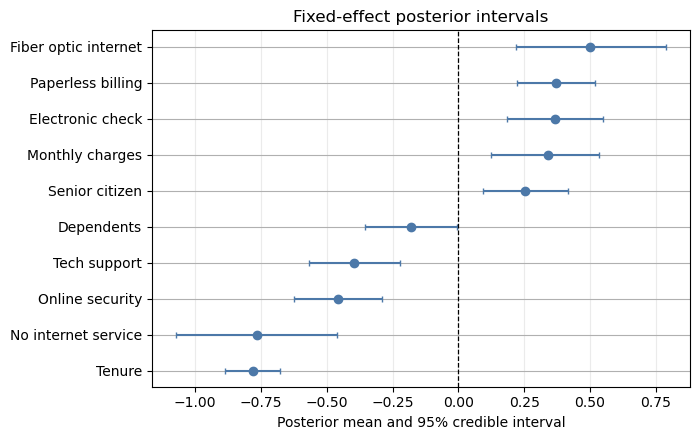

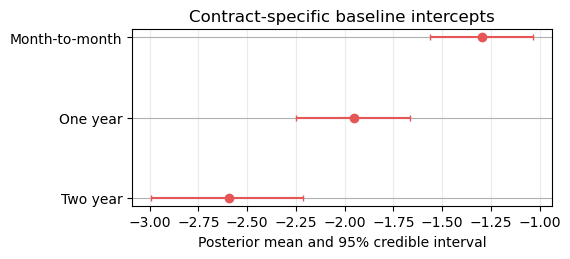

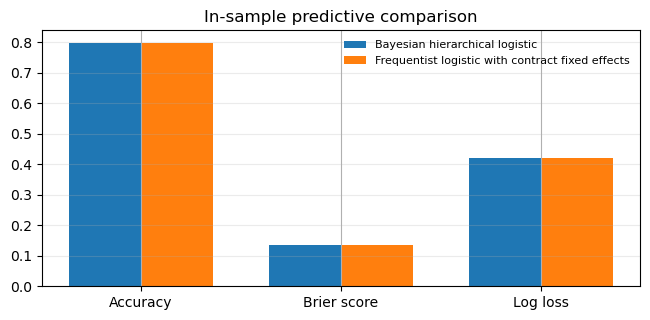

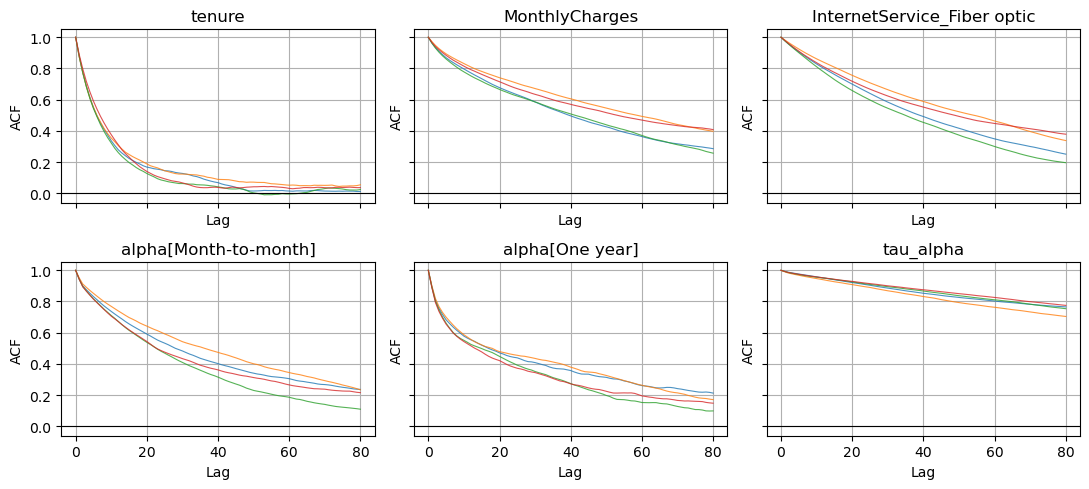

In [40]:
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Fixed-effect posterior interval figure.
fixed_names = [
    "tenure", "MonthlyCharges", "SeniorCitizen", "Dependents", "PaperlessBilling",
    "OnlineSecurity", "TechSupport", "InternetService_Fiber optic", "InternetService_No",
    "PaymentMethod_Electronic check",
]
fixed_plot = summary[summary["parameter"].isin(fixed_names)].copy()
fixed_plot["label"] = fixed_plot["parameter"].replace({
    "tenure": "Tenure",
    "MonthlyCharges": "Monthly charges",
    "SeniorCitizen": "Senior citizen",
    "Dependents": "Dependents",
    "PaperlessBilling": "Paperless billing",
    "OnlineSecurity": "Online security",
    "TechSupport": "Tech support",
    "InternetService_Fiber optic": "Fiber optic internet",
    "InternetService_No": "No internet service",
    "PaymentMethod_Electronic check": "Electronic check",
})
fixed_plot = fixed_plot.sort_values("mean")
y_pos = np.arange(len(fixed_plot))
fig, ax = plt.subplots(figsize=(7.1, 4.5))
ax.errorbar(
    fixed_plot["mean"],
    y_pos,
    xerr=[fixed_plot["mean"] - fixed_plot["q2.5"], fixed_plot["q97.5"] - fixed_plot["mean"]],
    fmt="o",
    color="#4C78A8",
    ecolor="#4C78A8",
    capsize=2,
)
ax.axvline(0, color="black", linewidth=0.9, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(fixed_plot["label"])
ax.set_xlabel("Posterior mean and 95% credible interval")
ax.set_title("Fixed-effect posterior intervals")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
fig.savefig(FIG_DIR / "posterior_fixed_effects.pdf", bbox_inches="tight")
plt.show()

# Contract intercept posterior interval figure.
alpha_plot = summary[summary["parameter"].str.startswith("alpha[")].copy()
alpha_plot["label"] = alpha_plot["parameter"].str.replace("alpha[", "", regex=False).str.replace("]", "", regex=False)
alpha_plot = alpha_plot.sort_values("mean")
y_pos = np.arange(len(alpha_plot))
fig, ax = plt.subplots(figsize=(5.8, 2.7))
ax.errorbar(
    alpha_plot["mean"],
    y_pos,
    xerr=[alpha_plot["mean"] - alpha_plot["q2.5"], alpha_plot["q97.5"] - alpha_plot["mean"]],
    fmt="o",
    color="#E45756",
    ecolor="#E45756",
    capsize=2,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(alpha_plot["label"])
ax.set_xlabel("Posterior mean and 95% credible interval")
ax.set_title("Contract-specific baseline intercepts")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
fig.savefig(FIG_DIR / "posterior_contract_intercepts.pdf", bbox_inches="tight")
plt.show()

# In-sample predictive comparison figure.
plot_metrics = comparison_metrics.melt(
    id_vars="model",
    value_vars=["accuracy_at_0.5", "brier_score", "log_loss"],
    var_name="metric",
    value_name="value",
)
metric_labels = {"accuracy_at_0.5": "Accuracy", "brier_score": "Brier score", "log_loss": "Log loss"}
plot_metrics["metric"] = plot_metrics["metric"].map(metric_labels)
fig, ax = plt.subplots(figsize=(6.6, 3.3))
width = 0.36
x = np.arange(3)
for i, (model_name, grp) in enumerate(plot_metrics.groupby("model")):
    vals = grp.set_index("metric").loc[["Accuracy", "Brier score", "Log loss"], "value"].to_numpy()
    ax.bar(x + (i - 0.5) * width, vals, width=width, label=model_name)
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Brier score", "Log loss"])
ax.set_title("In-sample predictive comparison")
ax.legend(frameon=False, fontsize=8)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(FIG_DIR / "model_comparison.pdf", bbox_inches="tight")
plt.show()

# Representative ACF diagnostics figure.
acf_params = ["tenure", "MonthlyCharges", "InternetService_Fiber optic", "alpha[Month-to-month]", "alpha[One year]", "tau_alpha"]
summary_index = {name: i for i, name in enumerate(param_names)}
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), acf_params):
    j = summary_index[name]
    for c in range(chain_draws.shape[0]):
        ac = autocorr(chain_draws[c, :, j], max_lag=80)
        ax.plot(np.arange(len(ac)), ac, linewidth=0.8, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
plt.tight_layout()
fig.savefig(FIG_DIR / "mcmc_acf_diagnostics.png", bbox_inches="tight", dpi=160)
plt.show()


## 10. Interpretation

The main project conclusions are:

1. **Prediction is similar to a frequentist logistic baseline.**  
   The Bayesian model should not be sold as a major accuracy improvement. Its advantage is uncertainty-aware inference with partial pooling across contract types.

2. **Contract type matters strongly.**  
   The hierarchical intercepts show that month-to-month customers have the highest baseline churn, while one-year and two-year contracts have lower baseline churn.

3. **Longer tenure is associated with lower churn.**  
   The posterior for tenure is clearly negative.

4. **Higher monthly charges are associated with higher churn.**  
   This remains even after accounting for contract type and service characteristics.

5. **Service and billing features matter.**  
   Online security and tech support tend to reduce churn, while paperless billing, fiber optic service, and electronic check payment tend to increase churn.

6. **The non-centered hierarchy improves the Bayesian computation.**  
   The model is substantively the same as the centered hierarchy, but sampling the standardized group effects `z_alpha` reduces posterior dependence among `alpha`, `mu_alpha`, and `tau_alpha`. The result is cleaner trace behavior and diagnostics that are easier to defend.

### Research question answered
Yes: the Bayesian hierarchical logistic model identifies both customer-level and contract-level drivers of churn, and shows meaningful heterogeneity in baseline churn across contract types. The value of the Bayesian approach is mainly inferential rather than predictive: it quantifies uncertainty, regularizes estimates through priors, and models contract-level baseline heterogeneity directly.


## 11. Save key outputs

This final cell writes out summaries you may want to reference in the report.


### Export Files Used by the Report

The final report pulls numerical values from these CSV files. Regenerating them from the notebook keeps the writeup tied to the actual computation rather than manually copied numbers.


In [44]:
summary.to_csv(OUTDIR / "posterior_summary.csv", index=False)
trace_df.to_csv(OUTDIR / "trace_small.csv", index=False)
metrics.to_csv(OUTDIR / "model_metrics.csv", index=False)
acceptance_rates.to_csv(OUTDIR / "acceptance_rates.csv", index=False)
step_history.to_csv(OUTDIR / "mh_step_adaptation.csv", index=False)
posterior_effect_probs.to_csv(OUTDIR / "posterior_effect_probabilities.csv", index=False)
comparison_metrics.to_csv(OUTDIR / "model_comparison_metrics.csv", index=False)
coefficient_comparison.to_csv(OUTDIR / "bayes_frequentist_coefficient_comparison.csv", index=False)
payment_summary.to_csv(OUTDIR / "payment_method_churn_summary.csv")

summary.head(), metrics, comparison_metrics


(        parameter    mean      sd    q2.5  median   q97.5  ess_bulk_approx  \
 0          tenure -0.7807  0.0535 -0.8850 -0.7813 -0.6766        1743.1331   
 1  MonthlyCharges  0.3385  0.1034  0.1256  0.3384  0.5358         270.4755   
 2   SeniorCitizen  0.2543  0.0829  0.0925  0.2540  0.4161        1353.3049   
 3         Partner  0.0100  0.0774 -0.1431  0.0104  0.1603        1237.6170   
 4      Dependents -0.1814  0.0886 -0.3554 -0.1805 -0.0070        1082.2967   
 
      rhat  
 0  1.0000  
 1  1.0023  
 2  1.0010  
 3  1.0015  
 4  1.0003  ,
    accuracy_at_0.5  brier_score  log_loss  posterior_mean_churn  \
 0           0.7996       0.1367      0.42                0.2658   
 
    posterior_churn_q2.5  posterior_churn_q97.5  
 0                0.2565                  0.275  ,
                                               model  accuracy_at_0.5  \
 0  Frequentist logistic with contract fixed effects           0.7996   
 1                    Bayesian hierarchical logistic        